In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

print("Setup complete.")

Setup complete.


In [4]:
df=pd.read_csv('penguins.csv')

## 练习1

In [5]:
def data_dic(df):
    rows,columns=df.shape
    measure_values=df.select_dtypes(include='number').columns.tolist()
    tag_values=df.select_dtypes(include='object').columns.tolist()
    print('rows:{},columns:{}'.format(rows,columns))
    print('-'*80)
    print('measure values:',measure_values)
    print('tag values:',tag_values)
    print('-'*80)
    df.info()
    print('-'*80)
    missing=df.isnull().sum()
    missing_columns=missing[missing>0].index.tolist()
    print(missing)
    print('-'*80)
    print(missing_columns)

In [6]:
data_dic(df)

rows:344,columns:7
--------------------------------------------------------------------------------
measure values: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
tag values: ['species', 'island', 'sex']
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
--------------------------------------------------------------------------------
species             

## 练习2

In [7]:
def observe(df):
    print("head (前5行):")
    print(df.head())
    
    print("\ntail (后5行):")
    print(df.tail())
    
    print("\nsample (随机5行):")
    print(df.sample(5, random_state=42))

In [8]:
observe(df)

head (前5行):
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  

tail (后5行):
    species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
339  Gentoo  Biscoe             NaN            NaN                NaN   
340  Gentoo  Biscoe            46.8           14.3              215.0   
341  Gentoo  Biscoe            50.4           15.7              222.0   
342  Gentoo  Biscoe            45.2           14.8              212.0   
343  Gentoo  Bi

head() 可能隐藏了数据末尾的物种（如Gentoo）或缺失值；
tail() 能发现末尾数据特征，sample() 可避免排序偏见。

## 练习3

In [9]:
print('整体描述：')
all_stats=df.describe()
print(all_stats)

stats=df['body_mass_g'].describe()
print("\n对body_mass_g列描述:\n",stats)
mean_val=stats['mean']
middle_val=stats['50%']
print('平均数：',mean_val)
print('中位数：',middle_val)
##右偏：右拖尾--->平均数受到影响大于中位数

if mean_val>middle_val:
    print('右偏')
elif mean_val<middle_val:
    print('左偏')
else:
    print('分布大致对称')


整体描述：
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000

对body_mass_g列描述:
 count     342.000000
mean     4201.754386
std       801.954536
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4750.000000
max      6300.000000
Name: body_mass_g, dtype: float64
平均数： 4201.754385964912
中位数： 4050.0
右偏


In [10]:
body_mass_g_min=all_stats['body_mass_g']['min']
body_mass_g_max=all_stats['body_mass_g']['max']
print(body_mass_g_min)
print(body_mass_g_max)

2700.0
6300.0


In [11]:
print(df.groupby('species')['body_mass_g'].min())

print("\n最小值所在行:")
print(df[df["body_mass_g"] == body_mass_g_max])

species
Adelie       2850.0
Chinstrap    2700.0
Gentoo       3950.0
Name: body_mass_g, dtype: float64

最小值所在行:
    species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
237  Gentoo  Biscoe            49.2           15.2              221.0   

     body_mass_g   sex  
237       6300.0  MALE  


## 练习4

In [12]:
print('各物种数量：')
df['species'].value_counts()
#若后续要比较不同物种的体重是否存在显著差异，当样本量最少的组（Chinstrap）与最多的组（Adelie）进行 t 检验时，
#检验的功效会降低（更难检测出真实差异）。另外，在构建分类模型时，模型可能会偏向预测多数类（Adelie），导致少数类（Chinstrap）的预测性能很差。

各物种数量：


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

## 练习5

In [13]:
missing=df.isnull().sum()
print(missing)

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [14]:
missing[missing==missing.max()]

sex    11
dtype: int64

In [15]:
df_dropped = df.dropna()
df_dropped

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [16]:
lost_rows = df.shape[0] - df_dropped.shape[0]
print(lost_rows)

11


In [17]:
print("\n损失在各物种中的分布（原始 vs 删除后）:")
origin_values=df['species'].value_counts()
print(origin_values)
current_values=df_dropped['species'].value_counts()
print(current_values)


损失在各物种中的分布（原始 vs 删除后）:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


In [18]:
table=pd.DataFrame({'原始数据':origin_values,'删减后数据':current_values})
table['删减数量']=table['原始数据']-table['删减后数据']
table['损失比例']=table['删减数量']/table['原始数据']
print(table)

           原始数据  删减后数据  删减数量      损失比例
species                               
Adelie      152    146     6  0.039474
Gentoo      124    119     5  0.040323
Chinstrap    68     68     0  0.000000


## 练习6

In [19]:
species_island=df.groupby(['species','island']).size().reset_index(name="count")
print("物种与岛屿分布:")
print(species_island)

物种与岛屿分布:
     species     island  count
0     Adelie     Biscoe     44
1     Adelie      Dream     56
2     Adelie  Torgersen     52
3  Chinstrap      Dream     68
4     Gentoo     Biscoe    124


In [20]:
all_island=set(df['island'].unique())
print(all_island)

{'Biscoe', 'Dream', 'Torgersen'}


In [21]:
print("\n出现在所有三个岛屿的物种:")
for sp in df['species'].unique():
    sp_island=set(df[df['species']==sp]['island'].unique())
    if len(all_island)==len(sp_island):
        print(sp)
        
    


出现在所有三个岛屿的物种:
Adelie


In [22]:
print("\n只出现在其中一个岛屿的物种:")
for sp in df['species'].unique():
    sp_island=set(df[df['species']==sp]['island'].unique())
    if len(sp_island)==1:
        print(sp)


只出现在其中一个岛屿的物种:
Chinstrap
Gentoo


## 练习7

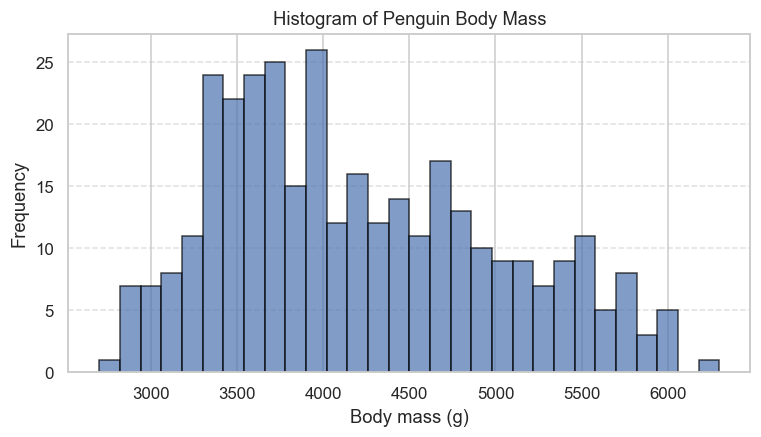

In [23]:
plt.figure(figsize=(8, 4))
plt.hist(df["body_mass_g"].dropna(), bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Body mass (g)")
plt.ylabel("Frequency")
plt.title("Histogram of Penguin Body Mass")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()



观察结论：直方图呈现多峰形态（至少两个明显峰），
表明数据并非来自单一均匀群体，可能隐藏着物种或性别分组。